# 🎯 Phase 3 Roadmap

Hum ye order follow karenge:

1. Data Cleaning
        ↓
2. Missing Values
        ↓
3. Duplicate Records
        ↓
4. Data Type Correction
        ↓
5. Feature Selection
        ↓
6. Data Leakage Detection
        ↓
7. Encoding
        ↓
8. Feature Engineering
        ↓
9. Train-Test Split
        ↓
10. Scaling
        ↓
11. SMOTE

# Customer Churn Prediction System

## Notebook 03: Data Preprocessing

### Objective

The objective of this notebook is to transform the raw dataset into a clean, machine-learning-ready dataset by handling missing values, correcting data types, selecting useful features, encoding categorical variables, scaling numerical features, and preparing the data for model training.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_excel("../data/raw/Telco_customer_churn.xlsx")

df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [4]:
df_clean = df.copy()

In [5]:
df_clean.shape

(7043, 33)

In [6]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

# Data Audit

The purpose of this section is to summarize the dataset structure before preprocessing.

In [6]:
data_audit = pd.DataFrame({
    "Data Type": df_clean.dtypes,
    "Missing Values": df_clean.isnull().sum(),
    "Missing (%)": round((df_clean.isnull().sum() / len(df_clean)) * 100, 2),
    "Unique Values": df_clean.nunique()
})

data_audit

,Data Type,Missing Values,Missing (%),Unique Values
CustomerID,str,0,0.00,7043
Count,int64,0,0.00,1
Country,str,0,0.00,1
State,str,0,0.00,1
City,str,0,0.00,1129
Zip Code,int64,0,0.00,1652
Lat Long,str,0,0.00,1652
Latitude,float64,0,0.00,1652
Longitude,float64,0,0.00,1651
Gender,str,0,0.00,2


In [7]:
data_audit.sort_values(
    by="Missing (%)",
    ascending=False
)

,Data Type,Missing Values,Missing (%),Unique Values
Churn Reason,str,5174,73.46,20
CustomerID,str,0,0.00,7043
Count,int64,0,0.00,1
State,str,0,0.00,1
Country,str,0,0.00,1
Zip Code,int64,0,0.00,1652
Lat Long,str,0,0.00,1652
Latitude,float64,0,0.00,1652
City,str,0,0.00,1129
Gender,str,0,0.00,2


# Feature Classification

Before preprocessing, each feature is classified based on its role in the machine learning pipeline.

This helps avoid unnecessary processing and prevents data leakage.

In [ ]:
drop_columns = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "Churn Value",
    "Churn Score",
    "Churn Reason"
]

In [7]:
df_clean["State"].value_counts()

State
California    7043
Name: count, dtype: int64

In [8]:
df_clean["Country"].value_counts()

Country
United States    7043
Name: count, dtype: int64

In [9]:
df_clean["City"].nunique()

1129

In [10]:
df_clean["City"].value_counts().head(10)

City
Los Angeles      305
San Diego        150
San Jose         112
Sacramento       108
San Francisco    104
Fresno            64
Long Beach        60
Oakland           52
Stockton          44
Glendale          40
Name: count, dtype: int64

In [11]:
df_clean["Zip Code"].nunique()

1652

In [12]:
df_clean[["Latitude", "Longitude"]].describe()

,Latitude,Longitude
count,7043.000000,7043.000000
mean,36.282441,-119.798880
std,2.455723,2.157889
min,32.555828,-124.301372
25%,34.030915,-121.815412
50%,36.391777,-119.730885
75%,38.224869,-118.043237
max,41.962127,-114.192901


In [13]:
drop_columns = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "Churn Value",
    "Churn Score",
    "Churn Reason",
    "Lat Long"
]

In [14]:
df_clean = df_clean.drop(columns=drop_columns)

In [15]:
df_clean.shape

(7043, 25)

In [16]:
df_clean.columns

Index(['City', 'Zip Code', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'CLTV'],
      dtype='str')

# Duplicate Records Analysis

Duplicate records can negatively impact model performance by introducing bias and redundant information.

In this section, we will identify duplicate rows and determine whether they should be removed before proceeding with further preprocessing.

In [17]:
# Check duplicate rows

duplicate_rows = df_clean.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_rows}")

Number of duplicate rows: 0


In [18]:
# Display duplicate rows (if any)

df_clean[df_clean.duplicated()]

,City,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,CLTV


In [19]:
# Check duplicate Customer IDs in the original dataset

df["CustomerID"].duplicated().sum()

np.int64(0)

## Observation

- No duplicate records were found in the dataset.
- Each customer record is unique.
- No duplicate removal is required.

## Business Insight

Since the dataset does not contain duplicate records, there is no risk of over-representing any customer during model training.

## ML Impact

No duplicate removal is required. The dataset can be used for further preprocessing without introducing bias caused by repeated observations.

# Missing Value Analysis

Missing values are common in real-world datasets and must be carefully analyzed before applying any imputation techniques.

The objective of this section is to identify missing values, understand why they exist, and decide the most appropriate treatment strategy based on business understanding.

In [20]:
# Count missing values in each column

missing_values = pd.DataFrame({
    "Missing Values": df_clean.isnull().sum(),
    "Missing Percentage": round((df_clean.isnull().sum() / len(df_clean)) * 100, 2)
})

missing_values = missing_values[missing_values["Missing Values"] > 0]

missing_values.sort_values(
    by="Missing Percentage",
    ascending=False
)

,Missing Values,Missing Percentage


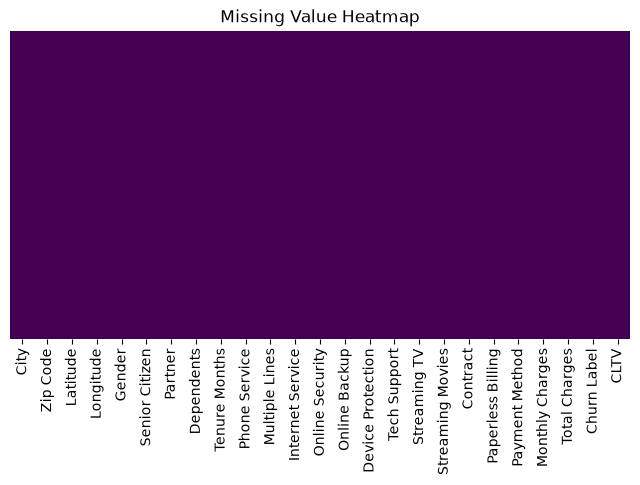

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))

sns.heatmap(
    df_clean.isnull(),
    cbar=False,
    yticklabels=False,
    cmap="viridis"
)

plt.title("Missing Value Heatmap")

plt.show()

In [24]:
df_clean.dtypes

City                     str
Zip Code               int64
Latitude             float64
Longitude            float64
Gender                   str
Senior Citizen           str
Partner                  str
Dependents               str
Tenure Months          int64
Phone Service            str
Multiple Lines           str
Internet Service         str
Online Security          str
Online Backup            str
Device Protection        str
Tech Support             str
Streaming TV             str
Streaming Movies         str
Contract                 str
Paperless Billing        str
Payment Method           str
Monthly Charges      float64
Total Charges         object
Churn Label              str
CLTV                   int64
dtype: object